In [16]:
#Now lets learn how to Evaluating a model

# a typical workflow you will go thorugh when building neural netwrokd is:

#build a model -> git it -> evaluate it -> tweak a model -> fit it -> evaluate it -> tweak a model -> fit it -> evalaute it...


# when evaluating a model we should visualize it:

#its a good idea to visualize:

  #1. the data: what data are we working with, what does it look like
  #2. the model itself: what does our model look like
  #3. the training of a model: how does a model performs while it learns
  #4. the prediction of the model: how do the predictions of a model line up against the gornd truth (the originla labels)?

  # for this we are gonna build a new data set (bigger dta set than the previous one)


import tensorflow as tf

x = tf.range(-100, 100, 4)
x


<tf.Tensor: shape=(50,), dtype=int32, numpy=
array([-100,  -96,  -92,  -88,  -84,  -80,  -76,  -72,  -68,  -64,  -60,
        -56,  -52,  -48,  -44,  -40,  -36,  -32,  -28,  -24,  -20,  -16,
        -12,   -8,   -4,    0,    4,    8,   12,   16,   20,   24,   28,
         32,   36,   40,   44,   48,   52,   56,   60,   64,   68,   72,
         76,   80,   84,   88,   92,   96], dtype=int32)>

In [17]:
#now lets make labels for the dataset
y = x + 10
y

<tf.Tensor: shape=(50,), dtype=int32, numpy=
array([-90, -86, -82, -78, -74, -70, -66, -62, -58, -54, -50, -46, -42,
       -38, -34, -30, -26, -22, -18, -14, -10,  -6,  -2,   2,   6,  10,
        14,  18,  22,  26,  30,  34,  38,  42,  46,  50,  54,  58,  62,
        66,  70,  74,  78,  82,  86,  90,  94,  98, 102, 106], dtype=int32)>

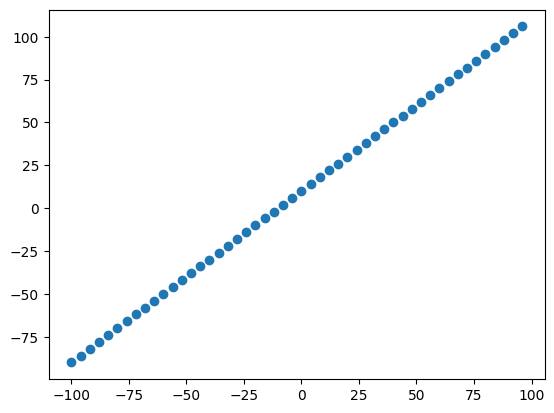

In [18]:
#now ets visualize the data

import matplotlib.pyplot as plt

plt.scatter(x,y)

In [19]:
# the 3 sets of data

#1. training set :- the model learns from this data, which is typically 70-80% of the total data you have available.
#2. Validation set :- the model gets tuned on this data, which is typically 10-15% of the data available
#3. Test set :- the model gets evaluated on this data to test what it has learned, this set is typically 1-15% of the total data available

# so lets split the data into train and test sets

x_train = x[:40] # first 40 are training samles (80% of the data)
y_train = y[:40]

x_test = x[40:] # last 10 are testing samples (20% of the data)
y_test = y[40:]

y_test



<tf.Tensor: shape=(10,), dtype=int32, numpy=array([ 70,  74,  78,  82,  86,  90,  94,  98, 102, 106], dtype=int32)>

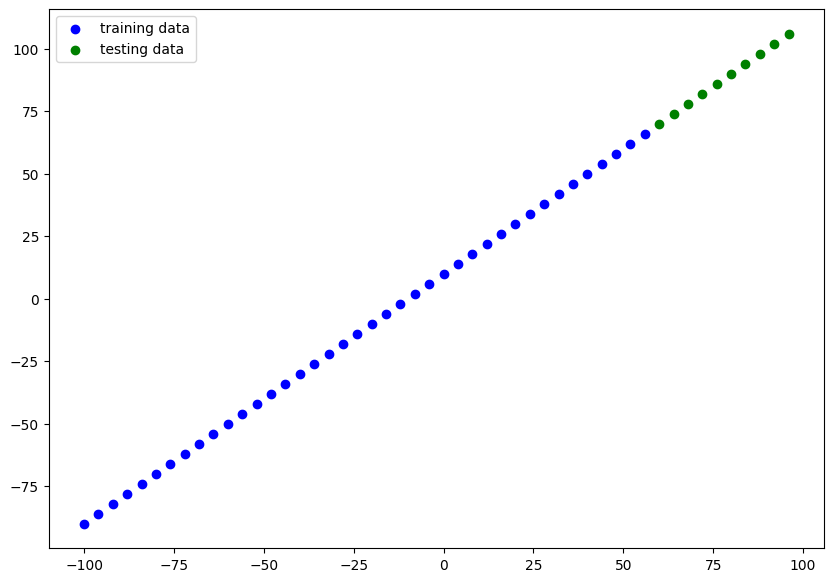

In [20]:
# lets visualize our training and testing data

plt.figure(figsize=(10,7))
plt.scatter(x_train, y_train, c="b", label="training data")

plt.scatter(x_test, y_test, c="g", label="testing data")
plt.legend()

In [21]:
#lets see how to build a neural network for our data

# 1. create a model:

model = tf.keras.Sequential([
    tf.keras.layers.Dense(1)
])

#2. compile the model
model.compile(loss=tf.keras.losses.mae, optimizer=tf.keras.optimizers.SGD(), metrics=["mae"])

#3. fit the model
#model.fit(x_train, y_train, epochs=100)

In [22]:
#befoe fitting the model lets visulaize the model

#meka use krnne model ek visulaize krnna
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [23]:
#api dan mulinma blmu input shape eke mokdda kiyla me odel building ekt adalawa
x[0], y[0]

#mekedi api balue x wala thyna eka value ekaka shape ek mokdd kiyl , dan api predict krddi denne hari nm x walal thiynna one value ekk neh
#ethkot x wala thiyna eka value ekke api predict krnna denwa nm danata x wala thiyna eka value ekaka input_shape ek mokdda
#eka thmai methnain balue

(<tf.Tensor: shape=(), dtype=int32, numpy=-100>,
 <tf.Tensor: shape=(), dtype=int32, numpy=-90>)

In [24]:
from os import name
#lets create a model which builds automatically by defining the input_shape argument

tf.random.set_seed(42)

model = tf.keras.Sequential([
    tf.keras.layers.Dense(10, input_shape=[1], name="datagetting_layer"),
    tf.keras.layers.Dense(1, name="output_layer")
], name="one_of_many_models_we_are_going_to_build")
#menna me uda widiyt thmai model ekai layers thiynwa nm e layers tikai name krnne wena wenama aduragnna

model.compile(loss=tf.keras.losses.mae, optimizer=tf.keras.optimizers.SGD(), metrics=["mae"])

model.fit(x_train, y_train, epochs=100, verbose=1)

Epoch 1/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step - loss: 38.8190 - mae: 38.8190 
Epoch 2/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - loss: 29.2621 - mae: 29.2621
Epoch 3/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - loss: 25.5084 - mae: 25.5084 
Epoch 4/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - loss: 20.2604 - mae: 20.2604
Epoch 5/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step - loss: 18.0282 - mae: 18.0282
Epoch 6/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - loss: 17.0380 - mae: 17.0380
Epoch 7/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step - loss: 11.4037 - mae: 11.4037
Epoch 8/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 218ms/step - loss: 15.2039 - mae: 15.2039
Epoch 9/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - loss: 15.9758 - mae: 15.9758 
Epoch 10/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step - loss: 11.9869 - mae: 11.9869
Epoch 11/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - loss: 14.9767 - mae: 14.9767
Epoch 12/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - loss: 11.0346 - mae: 11.0346
Epoch 13/100
2/

In [25]:
#lets define each things in table

#1. Total params: total numbers of parametrs in the mode, these are the patterns that the odel is gonna learn
#2. trainable parameters: these are arametrs (patterns) the model can update as it trains
#3. non trianble params: these parameters are not updated during training (this is typcal when you bring in already learn patterns or parametrs from other models duringtransfer learning)

model.summary()

Model: "one_of_many_models_we_are_going_to_build"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ datagetting_layer (Dense)       │ (None, 10)             │            20 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33 (136.00 B)

 Trainable params: 31 (124.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

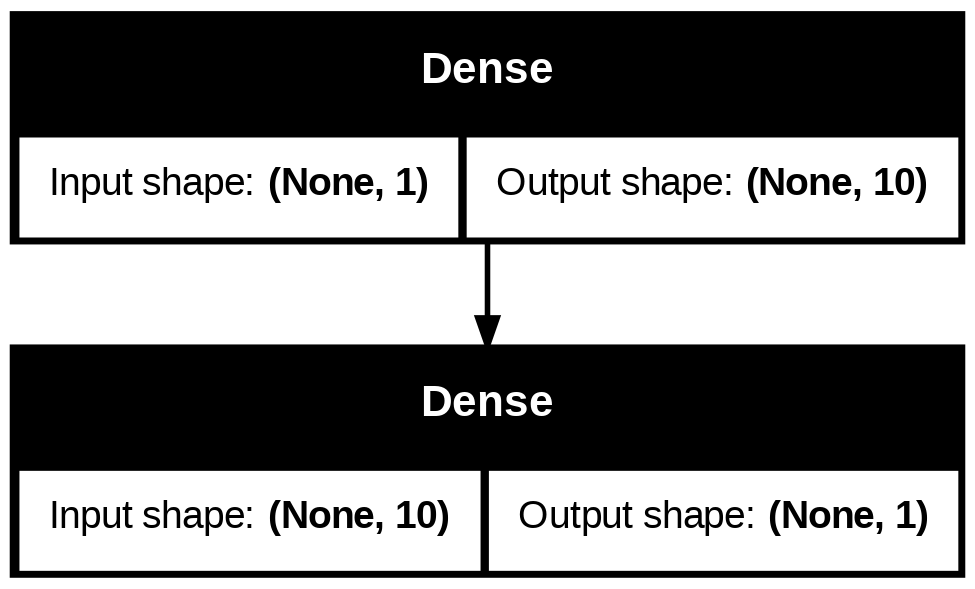

In [26]:
# there is another way to visulaize our model , by using plot model

from tensorflow.keras.utils import plot_model

plot_model(model=model, show_shapes=True)

In [27]:
#visualizing our model's predictions

# to visulaize prediction it is a good idea to plot them aganst the ground truth labels.
#often you will see this in the form of  y_test, y_true versus y_pred (ground truth versus your model's predictions)

# so lets make some predictions first

y_pred = model.predict(x_test)
y_pred, y_test

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step


(array([[34.003304],
        [36.16677 ],
        [38.330242],
        [40.49371 ],
        [42.657177],
        [44.820652],
        [46.98412 ],
        [49.147583],
        [51.311054],
        [53.474525]], dtype=float32),
 <tf.Tensor: shape=(10,), dtype=int32, numpy=array([ 70,  74,  78,  82,  86,  90,  94,  98, 102, 106], dtype=int32)>)

In [28]:
# uda predictions sahenna wardi , ut awlk nha eka model ekn ehma une khdm kiyla blagnna puluwan namth pai methna krnne ]plot krna ek (visulaize) hinda gaanak nha

#plot kranna function ekk hdla thiygu ethkot aaye aaye use krnna puluwanne



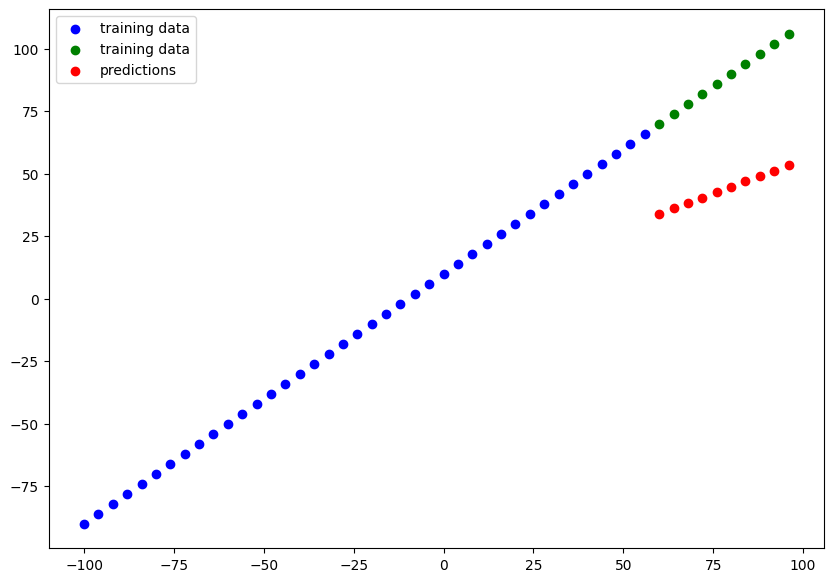

In [29]:
plot_predictions()

In [30]:
#look at the plot , red dot are not aligning wiht the test and training data , we can visualize it clearly here

In [31]:
# EVALUATING OUR MODEL'S PREDICTIONS WITH REGRESSION EVALUATION METRICS

# depending on the problem you are working on, there will be diffrenet evaluation metrics to evaluate your models's performance.

# since we are working on a regression, 2 of the main metrics:

  # MAE: mean absolute error, "on average, how wrong is each of my model's predictions"
  # MSE: mean square error, "square the average errors"


# so now lets evaluate on the test
model.evaluate(x_test, y_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step - loss: 44.2611 - mae: 44.2611


[44.261085510253906, 44.261085510253906]

In [32]:
#lets run a evaluation method mentioned in the lslides

#calculate the mean absolute error
tf.keras.losses.MAE(y_pred=tf.squeeze(y_pred), y_true=y_test)
#methna squeeze method ek damme okda y_test ekai y_pred eki dekema shape eka ekak krgnna one hinda

<tf.Tensor: shape=(), dtype=float32, numpy=44.261085510253906>

In [33]:
#calculate the mean square error:

mse = tf.keras.losses.MSE(y_pred=tf.squeeze(y_pred), y_true=y_test)
mse

<tf.Tensor: shape=(), dtype=float32, numpy=1986.8697509765625>

In [34]:
#to make things easier lets make some helper functions

def mae(y_true, y_pred):
  return tf.keras.losses.MAE(y_true=y_true, y_pred=y_pred)

def mse(y_true, y_pred):
  return tf.keras.losses.MSE(y_true=y_true, y_pred=y_pred)

In [35]:
# dan meke ara prshatharet anuwa red dots henama athin thiynne , dan blmu khmd ewa green dots ekk align wenna model ek improve krnne

#this is how we are gonna do it
#1. Get more data:- get more examples for your model to train on (more opportunities to lean patterns or realtionships between features and labels)
#2. make your model larger (using a more complex model)
#3. trian for longer(increasing the epochs)

#and lets see our datasets again

x_train, y_train

(<tf.Tensor: shape=(40,), dtype=int32, numpy=
 array([-100,  -96,  -92,  -88,  -84,  -80,  -76,  -72,  -68,  -64,  -60,
         -56,  -52,  -48,  -44,  -40,  -36,  -32,  -28,  -24,  -20,  -16,
         -12,   -8,   -4,    0,    4,    8,   12,   16,   20,   24,   28,
          32,   36,   40,   44,   48,   52,   56], dtype=int32)>,
 <tf.Tensor: shape=(40,), dtype=int32, numpy=
 array([-90, -86, -82, -78, -74, -70, -66, -62, -58, -54, -50, -46, -42,
        -38, -34, -30, -26, -22, -18, -14, -10,  -6,  -2,   2,   6,  10,
         14,  18,  22,  26,  30,  34,  38,  42,  46,  50,  54,  58,  62,
         66], dtype=int32)>)

In [36]:
# dan api mekedi menna me widiyt experiments krla blmu

#1. model_1 := same as the originla model, 1 layer trianed foe 100 epochs
#2. model_2 := 2 layers trianed for 100 epoch
#3. model_3 := layers, trianed for 500 epochs

In [37]:
#build model 1

tf.random.set_seed(42)

model_1 = tf.keras.Sequential([
    tf.keras.layers.Dense(1, input_shape=[1])
])

model_1.compile(loss=tf.keras.losses.mae,
                optimizer=tf.keras.optimizers.SGD(),
                metrics=["mae"])

model_1.fit(x_train, y_train, epochs=100)

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 83.8580 - mae: 83.8580 
Epoch 2/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 48.7252 - mae: 48.7252
Epoch 3/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 16.0103 - mae: 16.0103
Epoch 4/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 9.7821 - mae: 9.7821
Epoch 5/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 8.0613 - mae: 8.0613
Epoch 6/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 9.7705 - mae: 9.7705
Epoch 7/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 8.0435 - mae: 8.0435
Epoch 8/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 9.7589 - mae: 9.7589
Epoch 9/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 8.0256 - mae: 8.0256
Epoch 10/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 9.7473 - mae: 9.7473
Epoch 11/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 8.0078 - mae: 8.0078
Epoch 12/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 9.7356 - mae: 9.7356
Epoch 13/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - l

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step


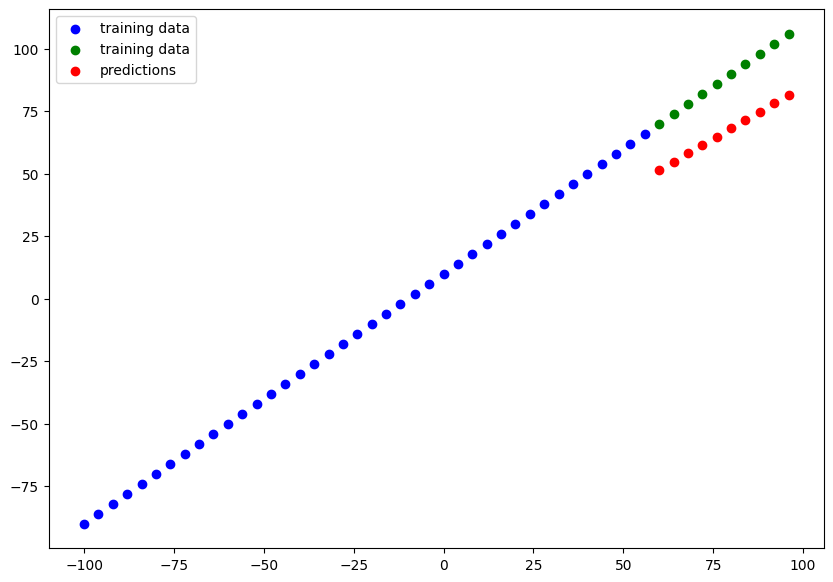

In [38]:
#make and plot predictions for model_1

y_pred_1 = model_1.predict(x_test)
plot_predictions(predictions=y_pred_1)

In [39]:
#calculate model_1 evalutation metrics

y_test.shape, y_pred_1.shape # hondta blnna y_pred eke shape ek y_test eke shape ekt samana nha so we have to squeeze it to remove 1 size dimensions

mae_1 = mae(y_test, tf.squeeze(y_pred_1))
mse_1 = mse(y_test, tf.squeeze(y_pred_1))

mae_1, mse_1

(<tf.Tensor: shape=(), dtype=float32, numpy=21.51849365234375>,
 <tf.Tensor: shape=(), dtype=float32, numpy=466.6573181152344>)

In [40]:
# okay now lets build the model number 2 - 2 dense layers with 100 epochs

tf.random.set_seed(42)

model_2 = tf.keras.Sequential([
    tf.keras.layers.Dense(10),
    tf.keras.layers.Dense(1)
])

#tensorFlow cannot train with that. It needs 2 dimensions.
x_train = tf.expand_dims(x_train, axis=-1)


model_2.compile(loss=tf.keras.losses.mae,
                optimizer=tf.keras.optimizers.SGD(),
                metrics=["mse"])

model_2.fit(x_train, y_train, epochs=100)

Epoch 1/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 57.9843 - mse: 4888.1538 
Epoch 2/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 26.7574 - mse: 1010.5657
Epoch 3/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 23.3612 - mse: 743.5553
Epoch 4/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 23.1536 - mse: 725.6967
Epoch 5/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 14.8684 - mse: 328.6914
Epoch 6/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 19.0988 - mse: 487.1815
Epoch 7/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 13.6913 - mse: 277.7077
Epoch 8/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 14.9179 - mse: 310.6622
Epoch 9/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 15.6967 - mse: 333.7691
Epoch 10/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 11.7405 - mse: 214.4340
Epoch 11/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 14.7052 - mse: 300.2064
Epoch 12/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 15.7448 - mse: 333.7198
Epoch 13/1

In [ ]:
#lets make and plot predictions of model_2

x_test = tf.expand_dims(x_test, axis=-1)

y_pred_2 = model_2.predict(x_test)
plot_predictions(predictions=y_pred_2)

In [ ]:
#meke anik codes kipaya aran giya elaga code file ekt , mekedi poddk patalenwa wage hinda